In [1]:
from pathlib import Path
import sys

# Add notebook directory so reactor_parameters can be found
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
_nb_dir = next((p for p in _candidates if (p / "reactor_parameters.py").is_file()), None)
if _nb_dir is not None and str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import numpy as np
import matplotlib.pyplot as plt

from reactor_parameters import *

from reactor_parameters import species_mass
T_mass = species_mass["T"]

# Reproduce standard DT operation

In [2]:
# ----- Standard DT species setup (50/50 D-T baseline) -----
species_params_standardDT = {
    "D": {
        "f_0": 0.5,
        "tau_p": tau_p_D,
        "tau_ifc": tau_ifc_D,
        "tau_ofc": tau_ofc_D,
        "N_stor_min": 0.0,
        "Ndot_max": np.inf,
        "N_ofc_0": 0.0,
        "N_ifc_0": 0.0,
        "N_stor_0": 1e50, # effectively infinite
        "enable_plasma_channel": True,
    },
    "T": {
        "f_0": 0.5,
        "tau_p": tau_p_T,
        "tau_ifc": tau_ifc_T,
        "tau_ofc": tau_ofc_T,
        "N_stor_min": 0.0,
        "Ndot_max": np.inf,
        "N_ofc_0": 0.0,
        "N_ifc_0": 0.0,
        "N_stor_0": 1.63 / T_mass,
        "enable_plasma_channel": True,
    },
    "He3": {
        "f_0": 0.0,
        "tau_p": tau_p_He3,
        "tau_ifc": tau_ifc_He3,
        "tau_ofc": tau_ofc_He3,
        "N_stor_min": 0.0,
        "Ndot_max": 0.0,
        "N_ofc_0": float(SPECIES_DEFAULTS["He3"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["He3"]["N_ifc_0"]),
        "N_stor_0": float(SPECIES_DEFAULTS["He3"]["N_stor_0"]),
        "enable_plasma_channel": True,
    },
    "He4": {
        "f_0": 0.0,
        "tau_p": tau_p_He4,
        "tau_ifc": tau_ifc_He4,
        "tau_ofc": tau_ofc_He4,
        "N_stor_min": 0.0,
        "Ndot_max": 0.0,
        "N_ofc_0": float(SPECIES_DEFAULTS["He4"]["N_ofc_0"]),
        "N_ifc_0": float(SPECIES_DEFAULTS["He4"]["N_ifc_0"]),
        "N_stor_0": float(SPECIES_DEFAULTS["He4"]["N_stor_0"]),
        "enable_plasma_channel": True,
    },
}

### Run setup

In [3]:
inject_from_storage_standardDT = {"D": True, "T": True, "He3": False, "He4": False}
injection_mode_standardDT = {"D": "auto", "T": "auto", "He3": "off", "He4": "off"}

species_params = {
    sp: {
        "tau_p": float(species_params_standardDT[sp]["tau_p"]),
        "lambda_decay": float(species_params_standardDT[sp].get("lambda_decay", SPECIES_DEFAULTS[sp]["lambda_decay"])),
        "tau_ifc": float(species_params_standardDT[sp]["tau_ifc"]),
        "tau_ofc": float(species_params_standardDT[sp]["tau_ofc"]),
        "N_stor_min": float(species_params_standardDT[sp]["N_stor_min"]),
        "Ndot_max": float(species_params_standardDT[sp]["Ndot_max"]),
        "inject_from_storage": bool(species_params_standardDT[sp].get("inject_from_storage", inject_from_storage_standardDT[sp])),
        "injection_mode": str(species_params_standardDT[sp].get("injection_mode", injection_mode_standardDT[sp])),
        "enable_plasma_channel": bool(species_params_standardDT[sp]["enable_plasma_channel"]),
    }
    for sp in SPECIES
}

initial_conditions = {
    sp: {
        "f_0": float(species_params_standardDT[sp]["f_0"]),
        "N_ofc_0": float(species_params_standardDT[sp]["N_ofc_0"]),
        "N_ifc_0": float(species_params_standardDT[sp]["N_ifc_0"]),
        "N_stor_0": float(species_params_standardDT[sp]["N_stor_0"]),
    }
    for sp in SPECIES
}

target_conditions_standardDT = [
    {
        "target_specie": "T",
        "metric": "stor",
        "value": 2.0 * float(initial_conditions["T"]["N_stor_0"]),
    }
]

reactivities_standardDT = compute_reactivities_from_functions(float(T_i))

injection_mix_weights_standardDT = {"D": 1.0, "T": 1.0}

### Solve

In [4]:
res_standardDT = solve_multispecies_ode_system(
    V_plasma=float(V_plasma),
    T_i=float(T_i),
    n_tot=float(n_tot),
    species_params=species_params,
    initial_conditions=initial_conditions,
    TBR_DT=TBR_DT,
    TBR_DDn=TBR_DD,
    max_simulation_time=float(max_simulation_time),
    vector_length=100000,
    reactivities=reactivities_standardDT,
    target_conditions=target_conditions_standardDT,
    injection_mix_weights=injection_mix_weights_standardDT,
)

In [5]:
# ----- Guard: check for solver failure -----
if not res_standardDT["sol_success"] and "t" not in res_standardDT:
    raise RuntimeError(
        f"Solver failed without returning time arrays.\n"
        f"  error: {res_standardDT.get('error', 'unknown')}\n"
        f"  Hint: N_stor_0=1e500 evaluates to inf; try a large but finite value (e.g. 1e30)."
    )

print("Standard DT-majority case")
print(f"  success(target reached) = {res_standardDT['sol_success']}")
if res_standardDT.get("error"):
    print(f"  error: {res_standardDT['error']}")
t_startup_standardDT = float(res_standardDT["t_startup"])
if not np.isfinite(t_startup_standardDT):
    t_startup_standardDT = float(np.asarray(res_standardDT["t"])[-1]) if len(np.asarray(res_standardDT["t"])) else np.nan
print(f"  t_startup = {t_startup_standardDT:.6e} s ({t_startup_standardDT/86400.0:.3f} d)")

Standard DT-majority case
  success(target reached) = True
  t_startup = 1.999852e+07 s (231.464 d)


### Fusion power

In [6]:
t_ref = np.asarray(res_standardDT["t"], dtype=float)
n_D = np.maximum(np.asarray(res_standardDT.get("n_D", np.zeros_like(t_ref)), dtype=float), 0.0)
n_T = np.maximum(np.asarray(res_standardDT.get("n_T", np.zeros_like(t_ref)), dtype=float), 0.0)
n_He3 = np.maximum(np.asarray(res_standardDT.get("n_He3", np.zeros_like(t_ref)), dtype=float), 0.0)

(
    P_DDn,
    P_DDp,
    P_DT,
    P_DHe3,
    P_TT,
    P_He3He3,
    P_THe3_ch1,
    P_THe3_ch2,
    P_THe3_ch3,
    P_DT_eq,
) = compute_fusion_power_profiles_numba(
    n_D,
    n_T,
    n_He3,
    float(n_tot),
    float(V_plasma),
    float(reactivities_standardDT["sigmav_DD_p"]),
    float(reactivities_standardDT["sigmav_DD_n"]),
    float(reactivities_standardDT["sigmav_DT"]),
    float(reactivities_standardDT["sigmav_DHe3"]),
    float(reactivities_standardDT["sigmav_TT"]),
    float(reactivities_standardDT["sigmav_He3He3"]),
    float(reactivities_standardDT["sigmav_THe3_ch1"]),
    float(reactivities_standardDT["sigmav_THe3_ch2"]),
    float(reactivities_standardDT["sigmav_THe3_ch3"]),
)

P_fusion_total = P_DDn + P_DDp + P_DT + P_DHe3 + P_TT + P_He3He3 + P_THe3_ch1 + P_THe3_ch2 + P_THe3_ch3
P_DDn = np.asarray(P_DDn, dtype=float)
P_DDp = np.asarray(P_DDp, dtype=float)
P_DT = np.asarray(P_DT, dtype=float)
P_DHe3 = np.asarray(P_DHe3, dtype=float)
P_TT = np.asarray(P_TT, dtype=float)
P_He3He3 = np.asarray(P_He3He3, dtype=float)
P_THe3_ch1 = np.asarray(P_THe3_ch1, dtype=float)
P_THe3_ch2 = np.asarray(P_THe3_ch2, dtype=float)
P_THe3_ch3 = np.asarray(P_THe3_ch3, dtype=float)
P_DT_eq = np.asarray(P_DT_eq, dtype=float)
P_fusion_total = np.asarray(P_fusion_total, dtype=float)
print(f"P_fus: {P_fusion_total[-1]/1e6:.3f} MW")

P_fus: 640.329 MW


### Plot

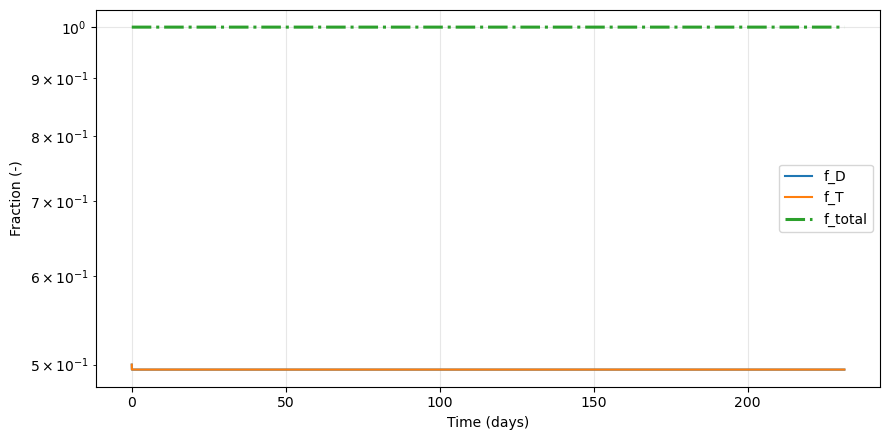

Final plasma composition:
  D: 7.424e+19 m^-3
    fraction: 4.949e-01
  T: 7.424e+19 m^-3
    fraction: 4.950e-01
  He3: 3.830e+15 m^-3
    fraction: 2.553e-05
  He4: 1.513e+18 m^-3
    fraction: 1.009e-02


In [7]:
# Plasma fractions
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_standardDT["t"], dtype=float) / 86400.0
for sp in ["D", "T"]:
    key = f"n_{sp}"
    if key in res_standardDT:
        ax.plot(t_days, np.asarray(res_standardDT[key], dtype=float) / n_tot, label=f"f_{sp}")
total = np.zeros_like(t_days, dtype=float)
for sp in SPECIES:
    key = f"n_{sp}"
    if key in res_standardDT:
        total = total + np.asarray(res_standardDT[key], dtype=float)
ax.plot(t_days, total / n_tot, lw=2.2, ls='-.', label="f_total")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Fraction (-)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# print final plasma composition
print("Final plasma composition:")
for sp in ["D", "T", "He3", "He4"]:
    key = f"n_{sp}"
    if key in res_standardDT:
        print(f"  {sp}: {np.asarray(res_standardDT[key], dtype=float)[-1]:.3e} m^-3")
        # fractions:
        print(f"    fraction: {np.asarray(res_standardDT[key], dtype=float)[-1]/n_tot:.3e}")

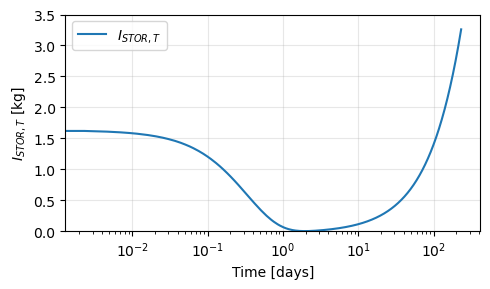

In [8]:
# T storage inventory
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
t_days = np.asarray(res_standardDT["t"], dtype=float) / 86400.0
t_seconds = np.asarray(res_standardDT["t"], dtype=float)
ax.plot(t_days, np.asarray(res_standardDT["N_stor_T"], dtype=float) * species_mass["T"], label="$I_{STOR,T}$")
ax.set_xlabel("Time [days]")
ax.set_ylabel("$I_{STOR,T}$ [kg]")
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(np.arange(0, t_days[-1] + 11, 30))
# ax.set_xlim(left=5e-1, right=5e7)
ax.set_yticks(np.arange(0, 1.65*2+0.5, 0.5))
#ax.set_yscale("log")
ax.set_xscale("log")
plt.tight_layout()
plt.show()


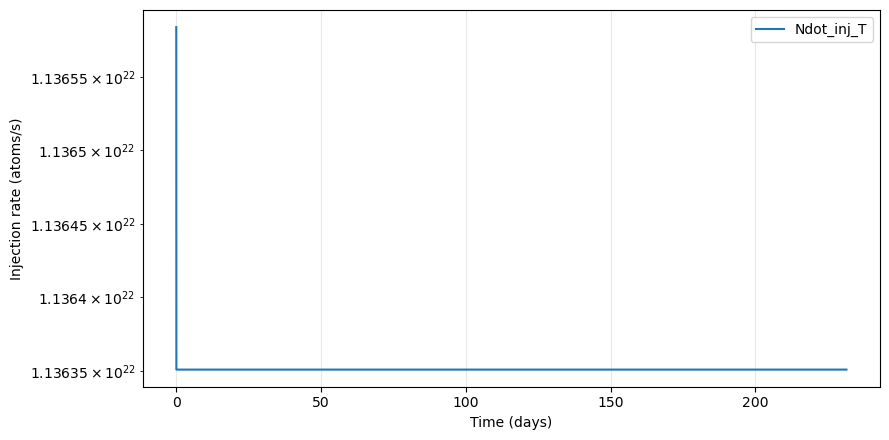

In [9]:
# T injection rate
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_standardDT["t"], dtype=float) / 86400.0
ax.plot(t_days, np.asarray(res_standardDT["Ndot_inj_T"], dtype=float), label="Ndot_inj_T")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Injection rate (atoms/s)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


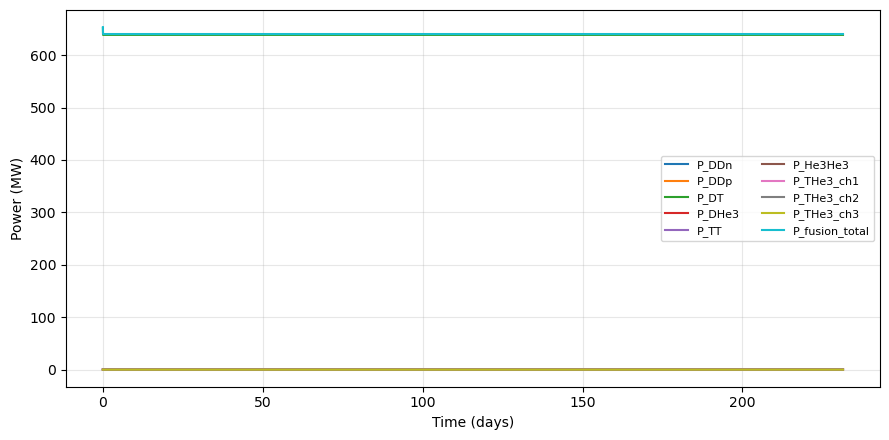

0.9973864428659341 fraction of DT in total fusion power


In [10]:
# Fusion powers
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
t_days = np.asarray(res_standardDT["t"], dtype=float) / 86400.0
reaction_series = [
    ("P_DDn", P_DDn),
    ("P_DDp", P_DDp),
    ("P_DT", P_DT),
    ("P_DHe3", P_DHe3),
    ("P_TT", P_TT),
    ("P_He3He3", P_He3He3),
    ("P_THe3_ch1", P_THe3_ch1),
    ("P_THe3_ch2", P_THe3_ch2),
    ("P_THe3_ch3", P_THe3_ch3),
    ("P_fusion_total", P_fusion_total),
]
for label, series in reaction_series:
    ax.plot(t_days, np.asarray(series, dtype=float) * 1.0e-6, label=label)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Power (MW)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print(P_DT[-1]/P_fusion_total[-1], "fraction of DT in total fusion power")

In [11]:
# ----- End-of-run tritium production and diffusion rates -----
n_D_end = float(np.asarray(res_standardDT["n_D"], dtype=float)[-1])
n_T_end = float(np.asarray(res_standardDT["n_T"], dtype=float)[-1])
print(f"End-of-run D density: {n_D_end:.3e} m^-3")
print(f"End-of-run T density: {n_T_end:.3e} m^-3")
# reactivities
print(f"End-of-run DT reactivity: {float(reactivities_standardDT['sigmav_DT']):.3e} m^3/s")
print(f"End-of-run DDn reactivity: {float(reactivities_standardDT['sigmav_DD_n']):.3e} m^3/s")
RrDT_end = n_D_end * n_T_end * float(reactivities_standardDT["sigmav_DT"]) * V_plasma
RrDDn_end = 0.5 * n_D_end * n_D_end * float(reactivities_standardDT["sigmav_DD_n"]) * V_plasma
RrTT_end = 0.5 * n_T_end * n_T_end * float(reactivities_standardDT["sigmav_TT"]) * V_plasma
print(f"reaction rates [atoms/s]: RrDT = {RrDT_end:.3e}")
tritium_breeding_rate = TBR_DT * RrDT_end + TBR_DD * RrDDn_end

taup_T = float(species_params["T"]["tau_p"])
T_diffusion_rate_end = (n_T_end / taup_T) * V_plasma
print(f"T burning rate (RrDT + RrTT): {(RrDT_end + RrTT_end):.3e} atoms/s")
print(f"T breeding rate (TBR_DT*RrDT + TBR_DD*RrDDn): {tritium_breeding_rate:.3e} atoms/s")
print(f"T diffusion rate (nT/taupT*Vp): {T_diffusion_rate_end:.3e} atoms/s")
print(f"Total T production rate (breeding + diffusion): {(tritium_breeding_rate + T_diffusion_rate_end):.3e} atoms/s")
print(f"T injection rate: {res_standardDT['Ndot_inj_T'][-1]:.3e} atoms/s")
print(f"Injection-diff-burning = {res_standardDT['Ndot_inj_T'][-1] - T_diffusion_rate_end - (RrDT_end + RrTT_end)}")

End-of-run D density: 7.424e+19 m^-3
End-of-run T density: 7.424e+19 m^-3
End-of-run DT reactivity: 2.739e-22 m^3/s
End-of-run DDn reactivity: 1.390e-24 m^3/s
reaction rates [atoms/s]: RrDT = 2.265e+20
T burning rate (RrDT + RrTT): 2.270e+20 atoms/s
T breeding rate (TBR_DT*RrDT + TBR_DD*RrDDn): 2.610e+20 atoms/s
T diffusion rate (nT/taupT*Vp): 1.114e+22 atoms/s
Total T production rate (breeding + diffusion): 1.140e+22 atoms/s
T injection rate: 1.136e+22 atoms/s
Injection-diff-burning = -8.362433794618163e+16


In [12]:
print(((RrDT_end+RrTT_end)/res_standardDT["Ndot_inj_T"])[-1])

0.019977618115564578
